In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

In [22]:
# Load dataset
df = pd.read_csv('./data/raw/watera.csv')
# Ambil kolom yang dibutuhkan (Potability tetap diambil untuk acuan label kotor)
df_filtered = df[['ph', 'tds', 'turbidity', 'potability']].dropna()
print(f'shape: {df.shape} --> setelah filter: {df_filtered.shape}')

shape: (100000, 10) --> setelah filter: (94578, 4)


In [30]:
df['potability'].value_counts()

potability
0    92384
1     7616
Name: count, dtype: int64

In [23]:
# Simulasi suhu air toren di Indonesia (berkisar antara 24°C hingga 32°C)
# Kita tambahkan sedikit variasi acak (noise)
total_rows = len(df_filtered)
df_filtered['temperature'] = np.random.uniform(25.0, 32.0, size=total_rows)
df_filtered.head()

,ph,tds,turbidity,potability,temperature
0,7.14,614.26,2.23,0,25.381315
1,6.41,387.89,2.07,0,30.308646
2,6.29,225.55,5.05,0,25.415141
3,7.39,459.23,2.26,0,25.908733
4,6.31,308.99,5.30,0,25.344020


In [24]:
df_filtered[['ph', 'tds', 'turbidity', 'temperature']].describe()

,ph,tds,turbidity,temperature
count,94578.000000,94578.000000,94578.000000,94578.000000
mean,7.249373,330.194234,3.137993,28.497530
std,0.996220,246.061051,2.413709,2.022503
min,5.000000,0.030000,0.000000,25.000029
25%,6.490000,160.470000,1.450000,26.745923
50%,7.240000,269.990000,2.660000,28.498500
75%,7.970000,378.350000,4.300000,30.251102
max,9.990000,1099.990000,13.990000,31.999977


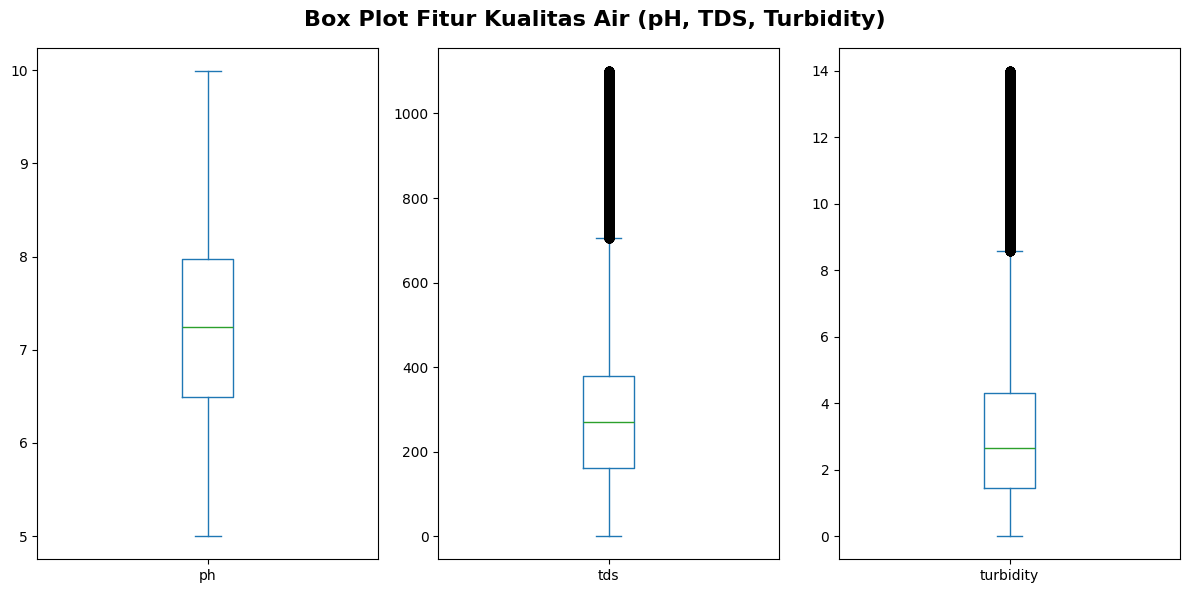

In [25]:
# 1. Memilih hanya kolom yang diinginkan
# gaya_outlier = dict(marker='o', markersize=3, alpha=0.1, markerfacecolor='black', markeredgecolor='none')
kolom_pilihan = ['ph', 'tds', 'turbidity']

# 2. Membuat Box Plot
# Layout diubah menjadi (1, 3) karena sekarang hanya ada 3 grafik
df_filtered[kolom_pilihan].plot(
    kind='box', 
    subplots=True, 
    layout=(1, 3), 
    figsize=(12, 6), # Ukuran disesuaikan agar proporsional untuk 3 grafik
    # flierprops=gaya_outlier # <--- Ini kuncinya!
)

# 3. Menambahkan Judul Utama di tengah (Center)
plt.suptitle('Box Plot Fitur Kualitas Air (pH, TDS, Turbidity)', fontsize=16, fontweight='bold', ha='center')

# 4. Merapikan tata letak agar judul tidak menabrak grafik
plt.tight_layout()

# Menampilkan grafik
plt.show()

In [26]:
def remove_extreme_outliers(dataframe):
    df_clean = dataframe.copy()
    
    # 1. Pembersihan Kolom pH (Batas Dua Arah)
    # Menggunakan pengali 1.5 (Ekstrem) agar fluktuasi asam/basa yang alami tetap aman
    Q1_ph = df_clean['ph'].quantile(0.25)
    Q3_ph = df_clean['ph'].quantile(0.75)
    IQR_ph = Q3_ph - Q1_ph
    
    batas_bawah_ph = Q1_ph - 1.5 * IQR_ph
    batas_atas_ph = Q3_ph + 1.5 * IQR_ph
    
    # Filter pH (Serta pastikan secara fisik tidak keluar dari rentang standar 0-14)
    df_clean = df_clean[
        (df_clean['ph'] >= max(0, batas_bawah_ph)) & 
        (df_clean['ph'] <= min(14, batas_atas_ph))
    ]
    
    # 2. Pembersihan Kolom tds & turbidity (Fokus Longgar pada Batas Atas)
    # Kita ingin mempertahankan air sekotor mungkin, jadi batas atas dinaikkan sangat tinggi (1.5 * IQR)
    for col in ['tds', 'turbidity']:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        batas_atas_ekstrem = Q3 + 1.5 * IQR
        
        # Filter: Buang nilai minus/nol yang mustahil secara fisik, 
        # dan buang yang di atas batas ekstrem saja
        df_clean = df_clean[
            (df_clean[col] > 0) & 
            (df_clean[col] <= batas_atas_ekstrem)
        ]
        
    return df_clean

# Eksekusi fungsi baru
df_filtered_clean = remove_extreme_outliers(df_filtered)

print(f"Jumlah baris awal: {len(df_filtered)}")
print(f"Jumlah baris setelah membuang outlier ekstrem: {len(df_filtered_clean)}")
print(f"Data yang berhasil diselamatkan: {len(df_filtered_clean) - 2400 if 'tergantung_hasil' else 'Banyak data kotor natural tetap aman!'}")

Jumlah baris awal: 94578
Jumlah baris setelah membuang outlier ekstrem: 80061
Data yang berhasil diselamatkan: 77661


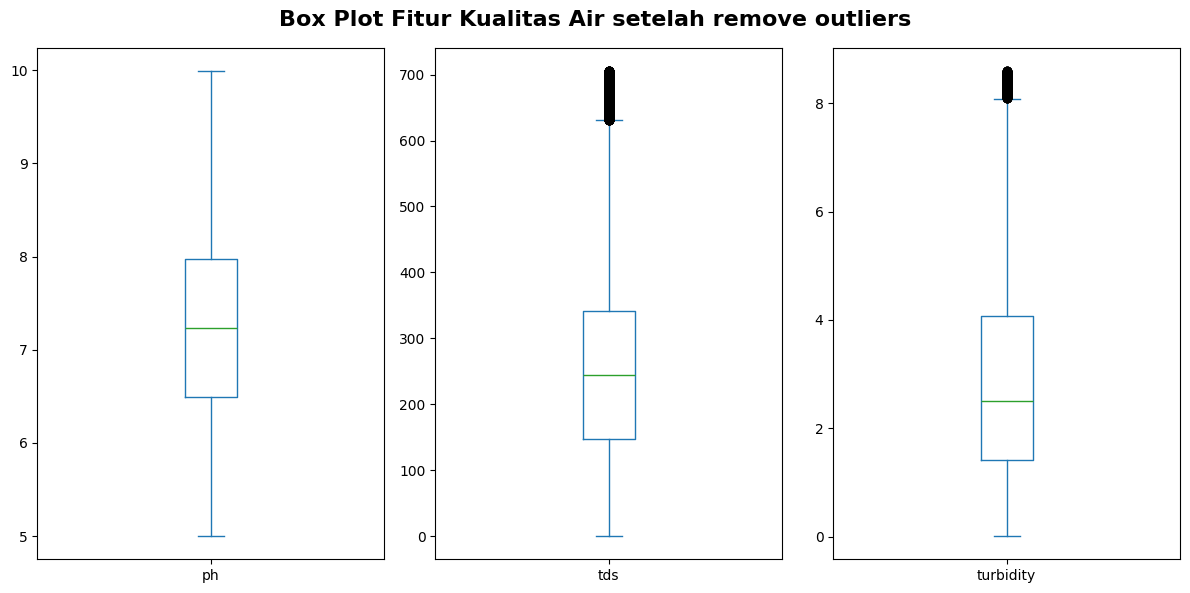

In [27]:
df_filtered_clean[kolom_pilihan].plot(
    kind='box', 
    subplots=True, 
    layout=(1, 3), 
    figsize=(12, 6), # Ukuran disesuaikan agar proporsional untuk 3 grafik
    # flierprops=gaya_outlier # <--- Ini kuncinya!
)

# 3. Menambahkan Judul Utama di tengah (Center)
plt.suptitle('Box Plot Fitur Kualitas Air setelah remove outliers', fontsize=16, fontweight='bold', ha='center')

# 4. Merapikan tata letak agar judul tidak menabrak grafik
plt.tight_layout()

# Menampilkan grafik
plt.show()

In [28]:
df_filtered_clean.describe()

,ph,tds,turbidity,potability,temperature
count,80061.000000,80061.000000,80061.000000,80061.000000,80061.000000
mean,7.247265,257.128935,2.765476,0.089707,28.497017
std,0.997336,139.858034,1.669397,0.285763,2.024528
min,5.000000,0.030000,0.010000,0.000000,25.000029
25%,6.490000,147.990000,1.410000,0.000000,26.739829
50%,7.230000,244.940000,2.500000,0.000000,28.494348
75%,7.970000,341.350000,4.080000,0.000000,30.253382
max,9.990000,705.130000,8.590000,1.000000,31.999977


In [29]:
# Menghitung jumlah masing-masing nilai di kolom potability
df_filtered['potability'].value_counts()

potability
0    87384
1     7194
Name: count, dtype: int64

In [34]:
print("1. Mengekstrak profil kualitas air dari dataset asli...")
# Mengambil nilai rata-rata (mean) dan standar deviasi (std) sebagai batas acuan simulasi
profil_bersih = df_filtered[df_filtered['potability'] == 1].describe()
profil_kotor = df_filtered[df_filtered['potability'] == 0].describe()

# ==========================================
# FASE 1: GENERATE DATA TIME-SERIES
# ==========================================
print("2. Memulai simulasi pergerakan degradasi air (1.000 Siklus)...")
jumlah_siklus = 1000 
data_time_series = []

np.random.seed(42)

for siklus in range(1, jumlah_siklus + 1):
    total_hari = np.random.randint(60, 101) 
    
    for hari in range(1, total_hari + 1):
        rasio_waktu = hari / total_hari
        
        # pH
        ph_start = profil_bersih.loc['mean', 'ph']
        ph_end = profil_kotor.loc['mean', 'ph']
        ph_current = ph_start + (ph_end - ph_start) * rasio_waktu + np.random.normal(0, profil_bersih.loc['std', 'ph'] * 0.1)
        
        # Solids (TDS)
        solids_start = profil_bersih.loc['mean', 'tds'] 
        solids_end = profil_kotor.loc['mean', 'tds']
        solids_current = solids_start + (solids_end - solids_start) * rasio_waktu + np.random.normal(0, profil_bersih.loc['std', 'tds'] * 0.1)
        
        # Turbidity 
        turb_start = profil_bersih.loc['mean', 'turbidity']
        turb_end = profil_kotor.loc['mean', 'turbidity']
        # Menggunakan pangkat 1.5 agar air keruhnya lambat di awal, tapi eksponensial di akhir
        turb_current = turb_start + (turb_end - turb_start) * (rasio_waktu ** 1.5) + np.random.normal(0, profil_bersih.loc['std', 'turbidity'] * 0.1)
        
        # Suhu
        temp_current = np.random.uniform(25.0, 32.0)
        
        rul = total_hari - hari
        
        data_time_series.append({
            'Cycle_ID': siklus,
            'Hari': hari,
            'ph': ph_current,
            'tds': solids_current,
            'turbidity': turb_current,
            'temperature': temp_current,
            'RUL': rul
        })

df_timeseries = pd.DataFrame(data_time_series)
print(f"   -> Berhasil membuat {len(df_timeseries)} baris data mentah.")

1. Mengekstrak profil kualitas air dari dataset asli...
2. Memulai simulasi pergerakan degradasi air (1.000 Siklus)...
   -> Berhasil membuat 80272 baris data mentah.


In [37]:
# ==========================================
# FASE 2: FEATURE ENGINEERING
# ==========================================
print("3. Menerapkan Feature Engineering (MA, Diff, Std)...")
# Pastikan data urut berdasarkan waktu sebelum dihitung
df_timeseries = df_timeseries.sort_values(by=['Cycle_ID', 'RUL'], ascending=[True, False])

fitur_sensor = ['turbidity', 'tds', 'ph']

# 1. Rolling Averages (Rata-rata bergerak 3 hari terakhir)
for col in fitur_sensor:
    df_timeseries[f'{col}_MA_3'] = df_timeseries.groupby('Cycle_ID')[col].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

# 2. Rate of Change (Selisih harian)
for col in fitur_sensor:
    df_timeseries[f'{col}_Diff'] = df_timeseries.groupby('Cycle_ID')[col].diff().fillna(0)

# 3. Volatilitas (Standard Deviation - 3 Hari)
for col in fitur_sensor:
    df_timeseries[f'{col}_Std_3'] = df_timeseries.groupby('Cycle_ID')[col].transform(lambda x: x.rolling(window=3, min_periods=1).std().fillna(0))

print("Fitur/kolom baru berhasil ditambahkan!")
print(df_timeseries[['Cycle_ID', 'RUL', 'turbidity', 'turbidity_MA_3', 'turbidity_Diff', 'turbidity_Std_3', 'tds', 'tds_MA_3', 'tds_Diff', 'tds_Std_3', 'ph', 'ph_MA_3', 'ph_Diff']].head())

3. Menerapkan Feature Engineering (MA, Diff, Std)...
Fitur/kolom baru berhasil ditambahkan!
   Cycle_ID  RUL  turbidity  turbidity_MA_3  turbidity_Diff  turbidity_Std_3  \
0         1   97   2.480309        2.480309        0.000000         0.000000   
1         1   96   2.289983        2.385146       -0.190326         0.134581   
2         1   95   2.429816        2.400036        0.139833         0.098596   
3         1   94   2.631563        2.450454        0.201748         0.171723   
4         1   93   2.351009        2.470796       -0.280555         0.144697   

          tds    tds_MA_3   tds_Diff  tds_Std_3        ph   ph_MA_3   ph_Diff  
0  210.960944  210.960944   0.000000   0.000000  7.201915  7.201915  0.000000  
1  207.164025  209.062485  -3.796920   2.684828  7.340568  7.271242  0.138653  
2  201.461774  206.528914  -5.702250   4.781326  7.270177  7.270887 -0.070391  
3  223.138475  210.588092  21.676701  11.236682  7.230391  7.280379 -0.039786  
4  208.477673  211.025974 -

In [ ]:
# ==========================================
# FASE 3: DATA SCALING / NORMALIZATION
# ==========================================
print("4. Melakukan Normalisasi Skala Data (0-1)...")

# Daftar 12 fitur yang akan masuk ke AI
fitur_x = [
    'ph', 'tds', 'turbidity', 'temperature',
    'turbidity_MA_3', 'tds_MA_3', 'ph_MA_3',
    'turbidity_Diff', 'tds_Diff', 'ph_Diff',
    'turbidity_Std_3', 'tds_Std_3'
]

scaler = MinMaxScaler()
df_scaled = df_timeseries.copy()

# Fit dan Transform
df_scaled[fitur_x] = scaler.fit_transform(df_scaled[fitur_x])

# Membuat folder models jika belum ada
os.makedirs('models', exist_ok=True)

# Simpan Scaler
with open('models/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Simpan Data Scaled yang siap di-training
df_scaled.to_csv('data/processed/data_toren_v2.csv', index=False)

print("\n" + "="*50)
print("PROSES SELESAI DENGAN SUKSES!")
print("="*50)
print("- Dataset siap training   : 'data_toren_v2.csv'")
print("- Memori Scaler AI        : 'models/scaler.pkl'")
print("\nLangkah selanjutnya: Buka terminal, pastikan berada di folder yang tepat, lalu jalankan 'python trainer.py'!")

4. Melakukan Normalisasi Skala Data (0-1)...

PROSES SELESAI DENGAN SUKSES!
- Dataset siap training   : 'data_toren_realistis_scaled.csv'
- Memori Scaler AI        : 'models/scaler.pkl'

Langkah selanjutnya: Buka terminal, pastikan berada di folder yang tepat, lalu jalankan 'python trainer.py'!
